In [2]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
%load_ext autoreload
%autoreload 2

%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [58]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [16]:
import os
from pathlib import Path

import numpy as np
import pandas as pd


def _image_label_from_key(k):
    return Path(str(k).replace("\\", "/")).stem


def _compute_fves_for_synapse(
    image_trials_by_label,
    sample_slice=slice(50, 100),
):
    """
    Parameters
    ----------
    image_trials_by_label : dict[str, np.ndarray]
        Maps image label -> array of shape (n_trials, n_time)
        for a single synapse.
    sample_slice : slice
        Peri-stimulus response window to use.

    Returns
    -------
    dict with:
        total_var
        mean_residual_var
        mean_fve
        image_fve_by_label
        image_incremental_fve_by_label
    """
    # ------------------------------------------------------------
    # Stack all image trials together
    # ------------------------------------------------------------
    labels = []
    trial_blocks = []

    for label, arr in image_trials_by_label.items():
        arr = np.asarray(arr, dtype=float)
        if arr.ndim != 2 or arr.shape[0] == 0:
            continue
        arr = arr[:, sample_slice]
        if arr.size == 0:
            continue

        trial_blocks.append(arr)
        labels.extend([label] * arr.shape[0])

    if len(trial_blocks) == 0:
        return None

    Y = np.concatenate(trial_blocks, axis=0)  # (n_all_trials, n_samples)
    labels = np.asarray(labels)

    valid = np.isfinite(Y)
    if valid.sum() < 2:
        return None

    # ------------------------------------------------------------
    # Total variance across all trials * all samples
    # ------------------------------------------------------------
    total_var = np.nanvar(Y.ravel())
    if not np.isfinite(total_var) or total_var <= 0:
        return None

    # ------------------------------------------------------------
    # Overall mean response trace across all image presentations
    # ------------------------------------------------------------
    overall_mean = np.nanmean(Y, axis=0)  # (n_samples,)
    Y_minus_mean = Y - overall_mean[None, :]
    mean_residual_var = np.nanvar(Y_minus_mean.ravel())
    mean_fve = 1.0 - (mean_residual_var / total_var)

    # ------------------------------------------------------------
    # For each image:
    # residual = image response - overall mean - image-specific mean residual
    #
    # We return two flavors:
    #
    # 1) image_fve_by_label:
    #    1 - Var(residual for this image) / total_var
    #
    # 2) image_incremental_fve_by_label:
    #    (Var(image-minus-overall-mean) - Var(final residual)) / total_var
    #
    # The first matches your wording most closely.
    # The second is the extra variance explained by image identity
    # on top of the overall mean.
    # ------------------------------------------------------------
    image_fve_by_label = {}
    image_incremental_fve_by_label = {}

    for label in image_trials_by_label.keys():
        mask = labels == label
        if mask.sum() == 0:
            image_fve_by_label[label] = np.nan
            image_incremental_fve_by_label[label] = np.nan
            continue

        Y_img = Y[mask]                       # image trials
        Y_img_minus_mean = Y_minus_mean[mask]

        # image-specific mean residual after removing overall mean
        image_mean_residual = np.nanmean(Y_img_minus_mean, axis=0)

        final_resid = Y_img_minus_mean - image_mean_residual[None, :]

        var_after_mean_within_img = np.nanvar(Y_img_minus_mean.ravel())
        var_final_within_img = np.nanvar(final_resid.ravel())

        image_fve_by_label[label] = 1.0 - (var_final_within_img / total_var)
        image_incremental_fve_by_label[label] = (
            var_after_mean_within_img - var_final_within_img
        ) / total_var

    return {
        "total_var": total_var,
        "mean_residual_var": mean_residual_var,
        "mean_fve": mean_fve,
        "image_fve_by_label": image_fve_by_label,
        "image_incremental_fve_by_label": image_incremental_fve_by_label,
    }


def compute_fves_across_sessions(
    single_trial_paths,
    assets,
    act_summary,
    sample_slice=slice(50, 100),
):
    """
    Compute Kaspar-style variance decomposition metrics across sessions.

    Parameters
    ----------
    single_trial_paths : list[str or Path]
        Paths to glutamate_single_trial_df.npz, aligned with `assets`.
    assets : list
        Asset objects aligned with single_trial_paths.
        Must provide:
            asset.session_id
            asset.metadata['dmd1_depth']
            asset.metadata['dmd2_depth']
    act_summary : pd.DataFrame
        Cumulative activation summary table across sessions.
        Must contain:
            session_id, dmd, synapse_id, stimulus_family, response_class
    sample_slice : slice
        Samples to use for the response window.

    Returns
    -------
    synapse_metrics_wide : pd.DataFrame
        One row per synapse with:
            mean_fve + seven image_fve_* columns
    synapse_metrics_long : pd.DataFrame
        Long-form version with one row per synapse x component
    depth_to_mean_fve : dict[int, np.ndarray]
        Mean-associated FVE values grouped by depth
    depth_to_image_fve : dict[int, dict[str, np.ndarray]]
        Image-associated FVE values grouped by depth and image
    """

    # ------------------------------------------------------------
    # Activated synapse lookup
    # ------------------------------------------------------------
    activated_lookup = (
        act_summary.loc[
            (act_summary["stimulus_family"] == "image")
            & (act_summary["response_class"] == "activated"),
            ["session_id", "dmd", "synapse_id"],
        ]
        .drop_duplicates()
    )

    activated_sets = {
        (sid, dmd): set(df["synapse_id"].tolist())
        for (sid, dmd), df in activated_lookup.groupby(["session_id", "dmd"])
    }

    # ------------------------------------------------------------
    # First pass: discover canonical image labels across sessions
    # ------------------------------------------------------------
    all_image_labels = set()
    for path in single_trial_paths:
        data = np.load(path, allow_pickle=True)["data"][0]
        for dmd_name in ["DMD1", "DMD2"]:
            if dmd_name not in data:
                continue
            if "image_identity" not in data[dmd_name]:
                continue
            all_image_labels.update(
                _image_label_from_key(k)
                for k in data[dmd_name]["image_identity"].keys()
            )

    all_image_labels = sorted(all_image_labels)

    # ------------------------------------------------------------
    # Main pass
    # ------------------------------------------------------------
    wide_rows = []
    long_rows = []

    depth_to_mean_fve = {25: [], 100: [], 200: [], 250: []}
    depth_to_image_fve = {
        25: {lab: [] for lab in all_image_labels},
        100: {lab: [] for lab in all_image_labels},
        200: {lab: [] for lab in all_image_labels},
        250: {lab: [] for lab in all_image_labels},
    }

    for i, path in enumerate(single_trial_paths):
        asset = assets[i]
        session_id = asset.session_id

        print(f"Processing {session_id}")

        data = np.load(path, allow_pickle=True)["data"][0]

        depth_map = {
            "DMD1": asset.metadata.get("dmd1_depth", np.nan),
            "DMD2": asset.metadata.get("dmd2_depth", np.nan),
        }

        for dmd_name in ["DMD1", "DMD2"]:
            if dmd_name not in data:
                continue
            if "image_identity" not in data[dmd_name]:
                continue

            activated_synapses = activated_sets.get((session_id, dmd_name), set())
            if len(activated_synapses) == 0:
                continue

            depth_um = depth_map[dmd_name]
            dmd_block = data[dmd_name]

            image_keys = list(dmd_block["image_identity"].keys())
            if len(image_keys) == 0:
                continue

            if "synapse_ids" in dmd_block:
                synapse_ids = np.asarray(dmd_block["synapse_ids"])
            else:
                first_im = dmd_block["image_identity"][image_keys[0]]
                synapse_ids = np.arange(first_im.shape[1])

            # build image arrays once
            image_arrays = {
                _image_label_from_key(k): np.asarray(dmd_block["image_identity"][k], dtype=float)
                for k in image_keys
            }

            n_synapses = next(iter(image_arrays.values())).shape[1]

            for syn_idx in range(n_synapses):
                synapse_id = synapse_ids[syn_idx]

                if synapse_id not in activated_synapses:
                    continue

                # collect all single-trial responses for this synapse
                image_trials_by_label = {}
                for label, arr in image_arrays.items():
                    # arr shape: (n_trials, n_synapses, n_time)
                    if syn_idx >= arr.shape[1]:
                        continue
                    syn_trials = arr[:, syn_idx, :]
                    image_trials_by_label[label] = syn_trials

                metrics = _compute_fves_for_synapse(
                    image_trials_by_label=image_trials_by_label,
                    sample_slice=sample_slice,
                )

                if metrics is None:
                    continue

                # wide row
                row = {
                    "session_id": session_id,
                    "subject_id": getattr(asset, "subject_id", np.nan),
                    "dmd": dmd_name,
                    "depth_um": depth_um,
                    "synapse_id": synapse_id,
                    "synapse_index": syn_idx,
                    "total_var": metrics["total_var"],
                    "mean_residual_var": metrics["mean_residual_var"],
                    "mean_fve": metrics["mean_fve"],
                }

                for lab in all_image_labels:
                    row[f"image_fve_{lab}"] = metrics["image_fve_by_label"].get(lab, np.nan)
                    row[f"image_incremental_fve_{lab}"] = metrics["image_incremental_fve_by_label"].get(lab, np.nan)

                wide_rows.append(row)

                # long rows
                long_rows.append(
                    {
                        "session_id": session_id,
                        "subject_id": getattr(asset, "subject_id", np.nan),
                        "dmd": dmd_name,
                        "depth_um": depth_um,
                        "synapse_id": synapse_id,
                        "component": "mean",
                        "stimulus_label": "overall_mean",
                        "fve": metrics["mean_fve"],
                        "fve_type": "mean_associated",
                    }
                )

                for lab in all_image_labels:
                    long_rows.append(
                        {
                            "session_id": session_id,
                            "subject_id": getattr(asset, "subject_id", np.nan),
                            "dmd": dmd_name,
                            "depth_um": depth_um,
                            "synapse_id": synapse_id,
                            "component": "image",
                            "stimulus_label": lab,
                            "fve": metrics["image_fve_by_label"].get(lab, np.nan),
                            "fve_type": "image_associated",
                        }
                    )

                # depth bins
                if depth_um in depth_to_mean_fve:
                    depth_to_mean_fve[depth_um].append(metrics["mean_fve"])
                    for lab in all_image_labels:
                        depth_to_image_fve[depth_um][lab].append(
                            metrics["image_fve_by_label"].get(lab, np.nan)
                        )

    synapse_metrics_wide = pd.DataFrame(wide_rows)
    synapse_metrics_long = pd.DataFrame(long_rows)

    # cast depth bins to arrays
    depth_to_mean_fve = {
        depth: np.asarray(vals, dtype=float)
        for depth, vals in depth_to_mean_fve.items()
    }
    depth_to_image_fve = {
        depth: {
            lab: np.asarray(vals, dtype=float)
            for lab, vals in lab_dict.items()
        }
        for depth, lab_dict in depth_to_image_fve.items()
    }

    return synapse_metrics_wide, synapse_metrics_long, depth_to_mean_fve, depth_to_image_fve

In [11]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [13]:
st_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_single_trial_df.npz'),recursive=True)[0] for asset in assets]

In [14]:
act_summary_path = r"C:\Users\andrew.shelton\Downloads\activation_summary.csv"
act_summary = pd.read_csv(act_summary_path)

In [17]:
synapse_metrics_wide, synapse_metrics_long, depth_to_mean_fve, depth_to_image_fve = (
    compute_fves_across_sessions(
        single_trial_paths=st_paths,
        assets=assets,
        act_summary=act_summary,
        sample_slice=slice(50, 100),
    )
)

Processing 803496_2025-07-25_13-02-10
Processing 803496_2025-07-28_08-04-39
Processing 803496_2025-07-29_13-34-35
Processing 803496_2025-07-30_10-05-23
Processing 803496_2025-07-31_09-43-28
Processing 803496_2025-08-01_13-22-49
Processing 804730_2025-07-25_14-08-35
Processing 804730_2025-07-28_13-57-34
Processing 804730_2025-07-29_14-55-04
Processing 804730_2025-07-30_11-11-11
Processing 804730_2025-07-31_11-45-27
Processing 804730_2025-08-01_14-22-38
Processing 804733_2025-07-25_15-17-00
Processing 804733_2025-07-28_19-00-06
Processing 804733_2025-07-29_16-02-24
Processing 804733_2025-07-30_12-59-44
Processing 804733_2025-07-31_13-29-01
Processing 804733_2025-08-01_15-20-32
Processing 810196_2025-07-25_16-24-20
Processing 810196_2025-07-28_19-59-05
Processing 810196_2025-07-29_17-02-41
Processing 810196_2025-07-31_08-28-08
Processing 810196_2025-07-31_14-19-46
Processing 810196_2025-08-01_16-37-27
Processing 809047_2025-10-29_10-16-32
Processing 809047_2025-10-30_10-06-43
Processing 8

In [46]:
depth_to_mean_fve

{25: array([0.00118372, 0.00882002, 0.01398218, ..., 0.00037483, 0.00072061,
        0.0003366 ]),
 100: array([1.78710127e-03, 1.77264219e-03, 1.02826900e-03, 1.14720874e-03,
        7.97590917e-04, 7.13867765e-04, 6.07663300e-03, 9.35912224e-03,
        3.68714986e-04, 4.87163457e-03, 1.11624339e-03, 1.14342432e-03,
        4.78031234e-04, 1.10993413e-03, 6.02855193e-04, 1.14621040e-03,
        3.36318439e-04, 4.82942116e-04, 4.97868543e-04, 5.91376043e-04,
        1.11005564e-03, 7.68122736e-04, 9.59450855e-04, 6.01111042e-04,
        5.71114839e-04, 7.22398688e-04, 1.85348511e-03, 5.22387400e-04,
        1.29173550e-03, 2.56322216e-03, 4.74236498e-04, 1.54917449e-03,
        2.30289195e-03, 4.91649642e-04, 5.35398818e-04, 1.32465458e-03,
        1.00580907e-03, 1.13020399e-03, 1.50163096e-03, 3.41326012e-03,
        3.59120149e-04, 1.06933729e-03, 1.86579300e-03, 8.13228049e-04,
        4.64165142e-04, 3.33066359e-03, 5.68602671e-04, 9.18851263e-04,
        3.58978588e-04, 5.574369

In [50]:
depth_list = [25]*len(depth_to_mean_fve[25]) + [100]*len(depth_to_mean_fve[100]) + [200]*len(depth_to_mean_fve[200]) + [250]*len(depth_to_mean_fve[250])

fve_df = pd.DataFrame(np.array([np.concatenate(list(depth_to_mean_fve.values())),depth_list]).T,columns=['fve','depth'])

In [51]:
depth_to_image_fve

{25: {'100075': array([        nan,         nan,         nan, ...,         nan,
                 nan, -0.01824811]),
  '216066': array([       nan,        nan,        nan, ...,        nan,        nan,
         0.09662933]),
  '268048': array([        nan,         nan,         nan, ...,         nan,
                 nan, -0.32067613]),
  '41006': array([       nan,        nan,        nan, ...,        nan,        nan,
         0.05660047]),
  '69022': array([       nan,        nan,        nan, ...,        nan,        nan,
         0.06362672]),
  'McGill_stairs': array([      nan,       nan,       nan, ...,       nan,       nan,
         0.2639278]),
  'imk00459': array([ 0.20343418, -0.29940891,  0.24290127, ...,         nan,
         -0.00074887,         nan]),
  'imk00895': array([0.09121055, 0.13156888, 0.19986383, ..., 0.00155932, 0.01713091,
                nan]),
  'imk00942': array([ 0.02154249,  0.22235222,  0.06719147, ...,  0.02441213,
         -0.0305466 ,         nan]),
  'i

In [52]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [53]:
cp = cp[::-1]

<IPython.core.display.Javascript object>


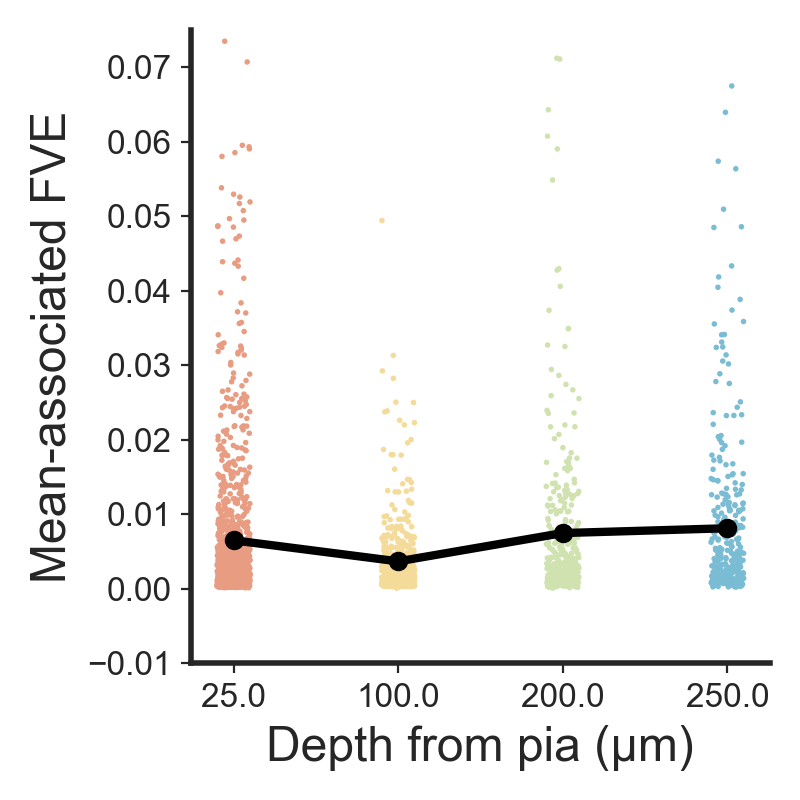

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_6856\1345236112.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = fve_df,x = 'depth', y = fve_df['fve'],palette=cp,size=2)


In [60]:
fig,ax=plt.subplots(figsize=(4,4))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','right','top','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()
    
sns.stripplot(data = fve_df,x = 'depth', y = fve_df['fve'],palette=cp,size=2)

means = [np.nanmean(fve) for fve in [depth_to_mean_fve[25],depth_to_mean_fve[100],depth_to_mean_fve[200],depth_to_mean_fve[250]]]
ax.plot(means,color='k',zorder=11,lw=3,marker='o')
ax.set_ylim(-0.01,0.075)

ax.set_ylabel('Mean-associated FVE')
ax.set_xlabel('Depth from pia (\u03BCm)')

fig.tight_layout()
filen = 'K-FVE-depth'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi= 300)

In [42]:
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# Pairwise depth comparisons
# ------------------------------------------------------------
depth_order = [25, 100, 200, 250]

pairwise_rows = []

for d1, d2 in itertools.combinations(depth_order, 2):
    x = fve_df.loc[fve_df["depth"] == d1, "fve"].dropna().to_numpy()
    y = fve_df.loc[fve_df["depth"] == d2, "fve"].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_rows.append(
        {
            "depth_1": d1,
            "depth_2": d2,
            "n_1": len(x),
            "n_2": len(y),
            "median_1": np.median(x),
            "median_2": np.median(y),
            "mean_1": np.mean(x),
            "mean_2": np.mean(y),
            "mw_u": stat,
            "p_uncorrected": p,
        }
    )

pairwise_stats = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# Multiple-comparisons correction
# ------------------------------------------------------------
reject, p_fdr, _, _ = multipletests(
    pairwise_stats["p_uncorrected"].values,
    alpha=0.05,
    method="fdr_bh",
)

pairwise_stats["p_fdr_bh"] = p_fdr
pairwise_stats["significant_fdr_bh"] = reject

pairwise_stats = pairwise_stats.sort_values("p_fdr_bh").reset_index(drop=True)

pairwise_stats

,depth_1,depth_2,n_1,n_2,median_1,median_2,mean_1,mean_2,mw_u,p_uncorrected,p_fdr_bh,significant_fdr_bh
0,100,250,656,341,0.001743,0.004047,0.003696,0.008142,73528.0,6.440903e-19,3.864542e-18,True
1,100,200,656,396,0.001743,0.002735,0.003696,0.007495,102890.0,1.562264e-08,4.686791e-08,True
2,25,250,1265,341,0.002475,0.004047,0.006526,0.008142,175927.0,1.689555e-07,3.379109e-07,True
3,25,100,1265,656,0.002475,0.001743,0.006526,0.003696,472408.0,6.150355e-07,9.225533e-07,True
4,200,250,396,341,0.002735,0.004047,0.007495,0.008142,58921.0,2.853991e-03,3.424789e-03,True
5,25,200,1265,396,0.002475,0.002735,0.006526,0.007495,235646.0,7.513432e-02,7.513432e-02,False


In [47]:
synapse_metrics_long

,session_id,subject_id,dmd,depth_um,synapse_id,component,stimulus_label,fve,fve_type
0,803496_2025-07-25_13-02-10,803496,DMD1,25,DMD1_syn0002,mean,overall_mean,0.001184,mean_associated
1,803496_2025-07-25_13-02-10,803496,DMD1,25,DMD1_syn0002,image,100075,NaN,image_associated
2,803496_2025-07-25_13-02-10,803496,DMD1,25,DMD1_syn0002,image,216066,NaN,image_associated
3,803496_2025-07-25_13-02-10,803496,DMD1,25,DMD1_syn0002,image,268048,NaN,image_associated
4,803496_2025-07-25_13-02-10,803496,DMD1,25,DMD1_syn0002,image,41006,NaN,image_associated
...,...,...,...,...,...,...,...,...,...
45181,838410_2026-03-20_10-00-59,838410,DMD2,25,DMD2_syn0012,image,imk01220,NaN,image_associated
45182,838410_2026-03-20_10-00-59,838410,DMD2,25,DMD2_syn0012,image,imk01306,NaN,image_associated
45183,838410_2026-03-20_10-00-59,838410,DMD2,25,DMD2_syn0012,image,imk01333,-0.063485,image_associated
45184,838410_2026-03-20_10-00-59,838410,DMD2,25,DMD2_syn0012,image,imk01378,NaN,image_associated
